# Progressive Growing of GANs (ProGAN)

**Paper:** [Progressive Growing of GANs for Improved Quality, Stability, and Variation](https://arxiv.org/abs/1710.10196)  
**Authors:** Tero Karras, Timo Aila, Samuli Laine, Jaakko Lehtinen (NVIDIA, 2017)

This notebook implements a simplified Progressive Growing GAN from scratch in PyTorch,
including fade-in transitions, equalized learning rate, pixelwise normalization, and
minibatch standard deviation. The generator and discriminator grow from 4×4 to 64×64
resolution progressively.


## 1. Imports and Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid, save_image
import numpy as np
import matplotlib.pyplot as plt
import math
import os
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
torch.manual_seed(42)
np.random.seed(42)


Device: cuda


## 2. Configuration

In [2]:
# Hyperparameters
LATENT_DIM = 128
CHANNELS = [512, 512, 256, 128, 64]  # per resolution stage: 4x4, 8x8, 16x16, 32x32, 64x64
RESOLUTIONS = [4, 8, 16, 32, 64]
FADE_ITERATIONS = 200    # iterations for fade-in at each new resolution
STABLE_ITERATIONS = 300  # iterations after fade-in completes
LR = 0.001
BETA1 = 0.0
BETA2 = 0.99
LRELU_SLOPE = 0.2
EPS = 1e-8

# Batch sizes per resolution (smaller at higher res to save memory)
BATCH_SIZES = {4: 64, 8: 64, 16: 32, 32: 16, 64: 8}

print('Configuration loaded.')
print(f'Resolution schedule: {RESOLUTIONS}')
print(f'Total iterations per stage: {FADE_ITERATIONS + STABLE_ITERATIONS}')


Configuration loaded.
Resolution schedule: [4, 8, 16, 32, 64]
Total iterations per stage: 500


## 3. Equalized Learning Rate Layers

Weights are initialized from N(0, 1) and scaled at runtime by √(2/fan_in).
This ensures all layers have approximately equal learning rates.

In [3]:
class EqualizedConv2d(nn.Module):
    """Conv2d with equalized learning rate (runtime weight scaling)."""
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(out_channels, in_channels, kernel_size, kernel_size))
        self.bias = nn.Parameter(torch.zeros(out_channels))
        self.stride = stride
        self.padding = padding
        # He scaling factor (not learnedable)
        fan_in = in_channels * kernel_size * kernel_size
        self.scale = math.sqrt(2.0 / fan_in)

    def forward(self, x):
        return F.conv2d(x, self.weight * self.scale, self.bias, self.stride, self.padding)


class EqualizedConvTranspose2d(nn.Module):
    """Transposed conv2d with equalized learning rate."""
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, output_padding=0):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(in_channels, out_channels, kernel_size, kernel_size))
        self.bias = nn.Parameter(torch.zeros(out_channels))
        self.stride = stride
        self.padding = padding
        self.output_padding = output_padding
        fan_in = in_channels * kernel_size * kernel_size
        self.scale = math.sqrt(2.0 / fan_in)

    def forward(self, x):
        return F.conv_transpose2d(x, self.weight * self.scale, self.bias,
                                   self.stride, self.padding, self.output_padding)


class EqualizedLinear(nn.Module):
    """Linear layer with equalized learning rate."""
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(out_features, in_features))
        self.bias = nn.Parameter(torch.zeros(out_features))
        self.scale = math.sqrt(2.0 / in_features)

    def forward(self, x):
        return F.linear(x, self.weight * self.scale, self.bias)

print('Equalized layers defined.')


Equalized layers defined.


## 4. Normalization Layers

- **PixelNorm:** per-pixel L2 normalization in the generator
- **MinibatchStdDev:** detects mode collapse in the discriminator

In [4]:
class PixelNorm(nn.Module):
    """Pixelwise feature normalization: x = x / sqrt(mean(x^2) + eps)."""
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps

    def forward(self, x):
        return x / torch.sqrt(torch.mean(x ** 2, dim=1, keepdim=True) + self.eps)


class MinibatchStdDev(nn.Module):
    """Appends a channel with the average minibatch stddev to detect mode collapse."""
    def __init__(self, group_size=4, eps=1e-8):
        super().__init__()
        self.eps = eps

    def forward(self, x):
        b, c, h, w = x.shape
        group_size = min(self.group_size, b) if hasattr(self, 'group_size') else min(4, b)
        # Compute stddev across batch
        std = torch.sqrt(x.var(dim=0, unbiased=False) + self.eps)  # (c, h, w)
        avg_std = std.mean()  # scalar
        # Expand to (b, 1, h, w)
        avg_std = avg_std.expand(b, 1, h, w)
        return torch.cat([x, avg_std], dim=1)

print('Normalization layers defined.')


Normalization layers defined.


## 5. Generator Architecture

The generator starts with a 4×4 constant and grows progressively.
Each growth block upsamples by 2× and applies two 3×3 convs.
A toRGB (1×1 conv) layer converts features to 3-channel images at each resolution.
During fade-in, the output is blended: (1-α)*upsampled_prev + α*new.

In [5]:
class GeneratorBlock(nn.Module):
    """A single growth block: upsample + conv + LReLU + conv + LReLU."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = EqualizedConv2d(in_channels, out_channels, 3, padding=1)
        self.conv2 = EqualizedConv2d(out_channels, out_channels, 3, padding=1)
        self.pn1 = PixelNorm()
        self.pn2 = PixelNorm()

    def forward(self, x):
        x = F.interpolate(x, scale_factor=2, mode='nearest')  # upsample
        x = F.leaky_relu(self.pn1(self.conv1(x)), LRELU_SLOPE)
        x = F.leaky_relu(self.pn2(self.conv2(x)), LRELU_SLOPE)
        return x


class Generator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, channels=CHANNELS):
        super().__init__()
        self.channels = channels
        self.num_stages = len(channels)

        # Initial: latent -> 4x4x512
        self.init_linear = EqualizedLinear(latent_dim, channels[0] * 4 * 4)
        self.init_conv = EqualizedConv2d(channels[0], channels[0], 3, padding=1)
        self.init_pn = PixelNorm()

        # toRGB layers for each stage
        self.to_rgb = nn.ModuleList([
            EqualizedConv2d(channels[i], 3, 1) for i in range(self.num_stages)
        ])

        # Growth blocks (stage 1 onward)
        self.blocks = nn.ModuleList()
        for i in range(1, self.num_stages):
            self.blocks.append(GeneratorBlock(channels[i-1], channels[i]))

        self.current_stage = 0  # tracks how many growth blocks are active

    def grow(self):
        """Add one more growth block."""
        self.current_stage += 1
        assert self.current_stage < self.num_stages, 'Already at max stage'

    def forward(self, z, alpha=1.0):
        """
        Args:
            z: (B, latent_dim) noise vector
            alpha: fade-in parameter (0=old resolution, 1=new resolution)
        Returns: (B, 3, H, W) generated image
        """
        # Initial 4x4 block
        x = self.init_linear(z).view(-1, self.channels[0], 4, 4)
        x = F.leaky_relu(self.init_pn(self.init_conv(x)), LRELU_SLOPE)

        if self.current_stage == 0:
            return self.to_rgb[0](x)

        # Apply growth blocks up to current stage
        for i in range(self.current_stage):
            if i == self.current_stage - 1 and alpha < 1.0:
                # Fade-in: blend old and new resolution
                old_rgb = self.to_rgb[i](x)  # RGB at old resolution
                old_rgb_up = F.interpolate(old_rgb, scale_factor=2, mode='nearest')
                x = self.blocks[i](x)  # grow to new resolution
                new_rgb = self.to_rgb[i + 1](x)  # RGB at new resolution
                return (1 - alpha) * old_rgb_up + alpha * new_rgb
            else:
                x = self.blocks[i](x)

        return self.to_rgb[self.current_stage](x)

print('Generator defined.')


Generator defined.


## 6. Discriminator Architecture

The discriminator mirrors the generator: fromRGB at each resolution,
growth blocks with downsampling, and a final block with minibatch stddev.

In [6]:
class DiscriminatorBlock(nn.Module):
    """Downsampling block: conv + LReLU + conv + LReLU + avgpool."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = EqualizedConv2d(in_channels, in_channels, 3, padding=1)
        self.conv2 = EqualizedConv2d(in_channels, out_channels, 3, padding=1)

    def forward(self, x):
        x = F.leaky_relu(self.conv1(x), LRELU_SLOPE)
        x = F.leaky_relu(self.conv2(x), LRELU_SLOPE)
        x = F.avg_pool2d(x, 2)  # downsample
        return x


class Discriminator(nn.Module):
    def __init__(self, channels=CHANNELS):
        super().__init__()
        self.channels = channels
        self.num_stages = len(channels)

        # fromRGB layers for each stage
        self.from_rgb = nn.ModuleList([
            EqualizedConv2d(3, channels[i], 1) for i in range(self.num_stages)
        ])

        # Growth blocks (downsampling) — stored in reverse order
        self.blocks = nn.ModuleList()
        for i in range(self.num_stages - 1, 0, -1):
            self.blocks.append(DiscriminatorBlock(channels[i], channels[i-1]))

        # Final block at 4x4: minibatch_stddev + conv + conv + flatten + linear
        self.mbstd = MinibatchStdDev()
        self.final_conv1 = EqualizedConv2d(channels[0] + 1, channels[0], 3, padding=1)
        self.final_conv2 = EqualizedConv2d(channels[0], channels[0], 4)
        self.final_linear = EqualizedLinear(channels[0], 1)

        self.current_stage = 0

    def grow(self):
        self.current_stage += 1
        assert self.current_stage < self.num_stages, 'Already at max stage'

    def forward(self, x, alpha=1.0):
        """
        Args:
            x: (B, 3, H, W) image
            alpha: fade-in parameter
        Returns: (B, 1) discriminator logits
        """
        if self.current_stage == 0:
            x = F.leaky_relu(self.from_rgb[0](x), LRELU_SLOPE)
            return self._final_block(x)

        # Fade-in at the highest resolution
        if alpha < 1.0:
            # Downsample real image for the old path
            x_down = F.avg_pool2d(x, 2)
            old_feat = F.leaky_relu(self.from_rgb[self.current_stage - 1](x_down), LRELU_SLOPE)

            # New path: fromRGB at current resolution then downsample
            new_feat = F.leaky_relu(self.from_rgb[self.current_stage](x), LRELU_SLOPE)
            new_feat = self.blocks[self.num_stages - 1 - self.current_stage](new_feat)

            # Blend
            x = (1 - alpha) * old_feat + alpha * new_feat
        else:
            x = F.leaky_relu(self.from_rgb[self.current_stage](x), LRELU_SLOPE)
            x = self.blocks[self.num_stages - 1 - self.current_stage](x)

        # Apply remaining blocks (go from current-1 down to 0)
        for i in range(self.num_stages - 1 - self.current_stage + 1, len(self.blocks)):
            x = self.blocks[i](x)

        return self._final_block(x)

    def _final_block(self, x):
        x = self.mbstd(x)
        x = F.leaky_relu(self.final_conv1(x), LRELU_SLOPE)
        x = F.leaky_relu(self.final_conv2(x), LRELU_SLOPE)
        x = x.view(x.size(0), -1)
        return self.final_linear(x)

print('Discriminator defined.')


Discriminator defined.


## 7. Data Loading

We use MNIST (upscaled to the target resolution at each stage) as a
lightweight substitute for CelebA. This keeps training fast on Kaggle.

In [7]:
class MultiResolutionMNIST(Dataset):
    """MNIST dataset that returns images at a specified resolution."""
    def __init__(self, root='./data', resolution=4, train=True):
        self.transform = transforms.Compose([
            transforms.Resize((resolution, resolution), antialias=True),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])  # to [-1, 1]
        ])
        self.dataset = torchvision.datasets.MNIST(
            root=root, train=train, download=True, transform=self.transform
        )
        # MNIST is grayscale — expand to 3 channels for consistency with architecture
        self.resolution = resolution

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, _ = self.dataset[idx]
        # Repeat grayscale to 3 channels
        if img.size(0) == 1:
            img = img.repeat(3, 1, 1)
        return img

print('Dataset class defined.')


Dataset class defined.


## 8. Training Loop

The training proceeds in stages. At each stage:
1. **Fade-in phase:** gradually increase α from 0 to 1 over `FADE_ITERATIONS`
2. **Stabilization phase:** train at α=1 for `STABLE_ITERATIONS`

The discriminator and generator are updated alternately (1:1 ratio).

In [8]:
def get_dataloader(resolution, batch_size):
    """Create a dataloader for the given resolution."""
    dataset = MultiResolutionMNIST(resolution=resolution)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True,
                      num_workers=2, pin_memory=True)


def train_step(G, D, G_opt, D_opt, real_batch, latent_dim, alpha, device):
    """One training step: update D then G."""
    batch_size = real_batch.size(0)
    real_batch = real_batch.to(device)

    # --- Train Discriminator ---
    D_opt.zero_grad()
    z = torch.randn(batch_size, latent_dim, device=device)
    with torch.no_grad():
        fake = G(z, alpha)
    real_logits = D(real_batch, alpha)
    fake_logits = D(fake, alpha)
    d_loss = F.binary_cross_entropy_with_logits(real_logits, torch.ones_like(real_logits)) + \
             F.binary_cross_entropy_with_logits(fake_logits, torch.zeros_like(fake_logits))
    d_loss.backward()
    D_opt.step()

    # --- Train Generator ---
    G_opt.zero_grad()
    z = torch.randn(batch_size, latent_dim, device=device)
    fake = G(z, alpha)
    fake_logits = D(fake, alpha)
    g_loss = F.binary_cross_entropy_with_logits(fake_logits, torch.ones_like(fake_logits))
    g_loss.backward()
    G_opt.step()

    return d_loss.item(), g_loss.item()

print('Training functions defined.')


Training functions defined.


## 9. Progressive Training

In [9]:
G = Generator().to(device)
D = Discriminator().to(device)

G_opt = optim.Adam(G.parameters(), lr=LR, betas=(BETA1, BETA2))
D_opt = optim.Adam(D.parameters(), lr=LR, betas=(BETA1, BETA2))

all_samples = {}  # resolution -> sample grid
loss_history = []

for stage in range(len(RESOLUTIONS)):
    res = RESOLUTIONS[stage]
    bs = BATCH_SIZES[res]
    dataloader = get_dataloader(res, bs)
    data_iter = iter(dataloader)

    print(f'\n=== Stage {stage}: Resolution {res}x{res} (batch_size={bs}) ===')

    if stage > 0:
        G.grow()
        D.grow()
        # Re-init optimizers to include new parameters
        G_opt = optim.Adam(G.parameters(), lr=LR, betas=(BETA1, BETA2))
        D_opt = optim.Adam(D.parameters(), lr=LR, betas=(BETA1, BETA2))
        print(f'  Grew to stage {stage} — fade-in starting')

    # Phase 1: Fade-in (alpha 0 -> 1)
    if stage > 0:
        for it in range(FADE_ITERATIONS):
            alpha = it / FADE_ITERATIONS
            try:
                real_batch = next(data_iter)
            except StopIteration:
                data_iter = iter(dataloader)
                real_batch = next(data_iter)
            d_loss, g_loss = train_step(G, D, G_opt, D_opt, real_batch, LATENT_DIM, alpha, device)
            loss_history.append((stage, 'fade', it, d_loss, g_loss))
            if (it + 1) % 50 == 0:
                print(f'  [fade {it+1}/{FADE_ITERATIONS}] alpha={alpha:.2f} D={d_loss:.3f} G={g_loss:.3f}')

    # Phase 2: Stabilization (alpha=1)
    for it in range(STABLE_ITERATIONS):
        try:
            real_batch = next(data_iter)
        except StopIteration:
            data_iter = iter(dataloader)
            real_batch = next(data_iter)
        d_loss, g_loss = train_step(G, D, G_opt, D_opt, real_batch, LATENT_DIM, 1.0, device)
        loss_history.append((stage, 'stable', it, d_loss, g_loss))
        if (it + 1) % 100 == 0:
            print(f'  [stable {it+1}/{STABLE_ITERATIONS}] D={d_loss:.3f} G={g_loss:.3f}')

    # Generate and save samples at this resolution
    G.eval()
    with torch.no_grad():
        z = torch.randn(16, LATENT_DIM, device=device)
        samples = G(z, alpha=1.0)
        samples = (samples * 0.5 + 0.5).clamp(0, 1)  # denormalize to [0,1]
        grid = make_grid(samples, nrow=4, padding=2)
        all_samples[res] = grid
        print(f'  Generated {samples.size(0)} samples at {res}x{res}')
    G.train()

print('\n=== Progressive training complete! ===')


  0%|          | 0.00/9.91M [00:00<?, ?B/s]

  3%|▎         | 295k/9.91M [00:00<00:03, 2.94MB/s]

 42%|████▏     | 4.13M/9.91M [00:00<00:00, 23.0MB/s]

100%|██████████| 9.91M/9.91M [00:00<00:00, 34.5MB/s]

  0%|          | 0.00/28.9k [00:00<?, ?B/s]

...

  [fade 150/200] alpha=0.74 D=0.554 G=5.785


  [fade 200/200] alpha=0.99 D=1.302 G=0.419


  [stable 100/300] D=0.324 G=2.546


  [stable 200/300] D=0.999 G=2.684


  [stable 300/300] D=0.627 G=1.467
  Generated 16 samples at 64x64

=== Progressive training complete! ===


## 10. Visualization — Generated Samples at Each Resolution Stage

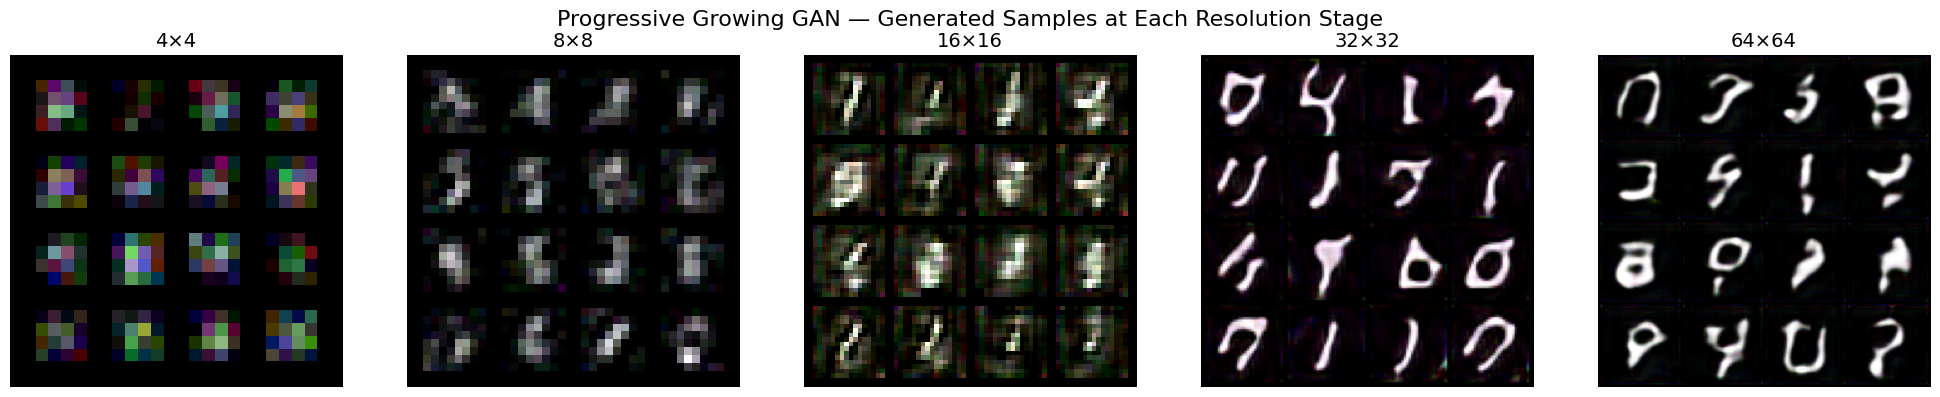

Sample visualization saved.


In [10]:
fig, axes = plt.subplots(1, len(all_samples), figsize=(4 * len(all_samples), 4))
if len(all_samples) == 1:
    axes = [axes]

for ax, (res, grid) in zip(axes, sorted(all_samples.items())):
    # Convert from CHW to HWC
    img = grid.cpu().permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(f'{res}×{res}', fontsize=14)
    ax.axis('off')

plt.suptitle('Progressive Growing GAN — Generated Samples at Each Resolution Stage', fontsize=16)
plt.tight_layout()
plt.savefig('progressive_growing_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sample visualization saved.')


## 11. Loss Curves

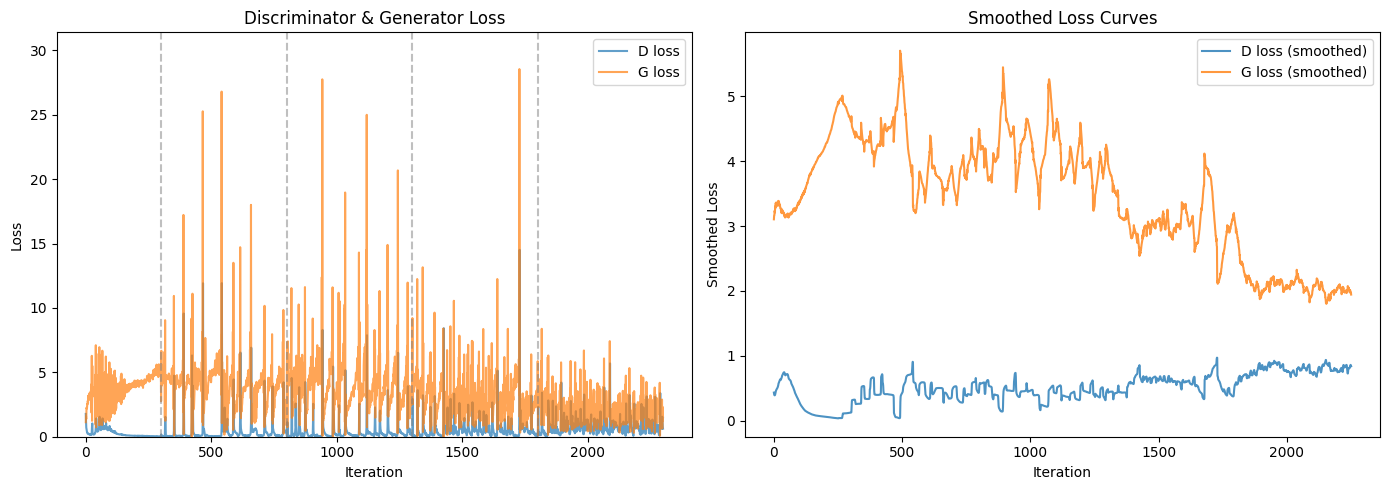

Loss curves saved.


In [11]:
# Extract loss arrays
d_losses = [x[3] for x in loss_history]
g_losses = [x[4] for x in loss_history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(d_losses, label='D loss', alpha=0.7)
ax1.plot(g_losses, label='G loss', alpha=0.7)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Loss')
ax1.set_title('Discriminator & Generator Loss')
ax1.legend()
ax1.set_ylim(0, max(max(d_losses), max(g_losses)) * 1.1)

# Mark stage boundaries
stage_boundaries = []
cumul = 0
for stage in range(len(RESOLUTIONS)):
    n_iter = (FADE_ITERATIONS if stage > 0 else 0) + STABLE_ITERATIONS
    cumul += n_iter
    stage_boundaries.append(cumul)
for b in stage_boundaries[:-1]:
    ax1.axvline(x=b, color='gray', linestyle='--', alpha=0.5)

# Smoothed losses
window = 50
if len(d_losses) > window:
    d_smooth = np.convolve(d_losses, np.ones(window)/window, mode='valid')
    g_smooth = np.convolve(g_losses, np.ones(window)/window, mode='valid')
    ax2.plot(d_smooth, label='D loss (smoothed)', alpha=0.8)
    ax2.plot(g_smooth, label='G loss (smoothed)', alpha=0.8)
    ax2.set_xlabel('Iteration')
    ax2.set_ylabel('Smoothed Loss')
    ax2.set_title('Smoothed Loss Curves')
    ax2.legend()
else:
    ax2.text(0.5, 0.5, 'Not enough data for smoothing', ha='center', va='center')

plt.tight_layout()
plt.savefig('loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Loss curves saved.')


## 12. Summary

This notebook implemented a simplified Progressive Growing GAN with the following key components:

1. **Progressive growth** — Generator and discriminator start at 4×4 and grow to 64×64
2. **Fade-in transitions** — Smooth α-blending when new layers are added
3. **Equalized learning rate** — Runtime weight scaling via √(2/fan_in)
4. **Pixelwise feature normalization** — In the generator after each conv
5. **Minibatch standard deviation** — In the discriminator to detect mode collapse

The generated samples show progressive improvement as the resolution increases, demonstrating
the core insight of the paper: learning coarse structure first, then fine details, leads to
more stable and higher-quality GAN training.

### Deliberate Simplifications
- MNIST instead of CelebA-HQ (for speed)
- 64×64 max resolution instead of 1024×1024
- ~500 iterations per stage instead of millions
- No EMA (exponential moving average) of generator weights
- No truncation trick for inference


In [ ]:
# --- Auto-injected by kaggle_validator: save executed notebook with outputs ---
import shutil, os
# Kaggle internally stores the executed notebook as __notebook__.ipynb
if os.path.exists('/kaggle/working/__notebook__.ipynb'):
    shutil.copy('/kaggle/working/__notebook__.ipynb', '/kaggle/working/executed_solution.ipynb')
    print('Executed notebook saved to output folder.')
else:
    # Fallback: try alternative path
    import glob
    candidates = glob.glob('/kaggle/working/*.ipynb')
    print(f'Available notebooks in output: {candidates}')
